# Imports

In [1]:
from pathlib import Path
import json
import os
import re
import subprocess
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import ndcg_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

/Users/kevinbauer/miniconda3/envs/vespa/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Paths

In [26]:
# Paths
DATA_DIR = Path("../../data")
EXPERIMENTAL_DIR = DATA_DIR / "experimental_datasets"
TOURNAMENT_DIR = DATA_DIR / "tournament"

FASTA_DIR = Path("FASTA")
RUN_ROOT = Path("vespa_runs")
CACHE_DIR = Path("prott5_cache")
OUTPUT_DIR = Path("vespa_zero_shot_outputs")
PETASE_OUTPUT_DIR = OUTPUT_DIR / "final_data"

for directory in [FASTA_DIR, RUN_ROOT, CACHE_DIR, OUTPUT_DIR, PETASE_OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RAW_SCORE_COL = "VESPAl"
SCORE_COL = "VESPA_score"  # standardized score used for evaluation/ranking
VARIANT_RE = re.compile(r"^([A-Z])(\d+)([A-Z])$")

# VESPA expects mutation positions in the mutation file to be 0-based.
# `position_base` describes the mutation numbering in the input CSV.
DATASET_CONFIG = {
    "UBE4B": {
        "path": EXPERIMENTAL_DIR / "ube4b_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "fasta_header": "UBE4B_WT",
        "protein_id": "UBE4B",
        "score_higher_is_better": True,
    },
    "GRB2": {
        "path": EXPERIMENTAL_DIR / "grb2_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "fasta_header": "GRB2_WT",
        "protein_id": "GRB2",
        "score_higher_is_better": True,
    },
    "PTEN_activity": {
        "path": EXPERIMENTAL_DIR / "pten-activity_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "fasta_header": "PTEN_ACTIVITY_WT",
        "protein_id": "PTEN_ACTIVITY",
        "score_higher_is_better": True,
    },
    "PTEN_abundance": {
        "path": EXPERIMENTAL_DIR / "pten-abundance_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "fasta_header": "PTEN_ABUNDANCE_WT",
        "protein_id": "PTEN_ABUNDANCE",
        "score_higher_is_better": True,
    },
    "Alpha-Amylase": {
        "path": TOURNAMENT_DIR / "Alpha-Amylase with WT(in silico_ Zero Shot).csv",
        "sep": "\t",
        "variant_col": "mutant",
        "sequence_col": "mutated_sequence",
        "target_cols": ["specific activity", "thermostability", "expression"],
        "position_base": 1,
        "fasta_header": "ALPHA_AMYLASE_WT",
        "protein_id": "ALPHA_AMYLASE",
        "score_higher_is_better": True,
        "filters": {
            "specific activity": (None, 3),
            "thermostability": (None, 3),
            "expression": (None, 3),
        },
        "reconstruct_wt_for_fasta": True,
    },
    "DLG4_abundance": {
        "path": "/Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/Final/test_data/dlg4-2022-abundance.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "fasta_header": "DLG4_ABUNDANCE_WT",
        "protein_id": "DLG4_ABUNDANCE",
        "score_higher_is_better": True,
    },
    "DLG4_binding": {
        "path": "/Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/Final/test_data/dlg4-2022-binding.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "fasta_header": "DLG4_BINDING_WT",
        "protein_id": "DLG4_BINDING",
        "score_higher_is_better": True,
    },
}

In [27]:
def parse_variant(variant: str):
    """Parse variants such as A123B into wild-type AA, numeric position and mutant AA."""
    match = VARIANT_RE.match(str(variant).strip().upper())
    if match is None:
        return None
    wt_aa, pos, mut_aa = match.groups()
    return wt_aa, int(pos), mut_aa


def to_position_1based(position: int, position_base: int) -> int:
    """Convert input mutation numbering to 1-based sequence numbering."""
    if position_base == 0:
        return position + 1
    if position_base == 1:
        return position
    raise ValueError("position_base must be either 0 or 1")


def to_vespa_key(variant: str, position_base: int) -> str | None:
    """Convert an input variant such as A123B to the 0-based VESPA key."""
    parsed = parse_variant(variant)
    if parsed is None:
        return None

    wt_aa, position, mut_aa = parsed
    position_0based = position if position_base == 0 else position - 1

    if position_0based < 0:
        return None

    return f"{wt_aa}{position_0based}{mut_aa}"


def reconstruct_wild_type_sequence(mutated_sequence: str, variant: str, position_base: int) -> str:
    """Reconstruct a WT sequence from a single-mutant sequence and a variant string."""
    parsed = parse_variant(variant)
    if parsed is None:
        raise ValueError(f"Invalid variant: {variant}")

    wt_aa, position, _ = parsed
    position_1based = to_position_1based(position, position_base)
    sequence = list(str(mutated_sequence))
    sequence[position_1based - 1] = wt_aa
    return "".join(sequence)

In [28]:
def load_dataset(dataset_name: str) -> tuple[pd.DataFrame, dict]:
    """Load one dataset and apply the dataset-specific lightweight filters."""
    config = DATASET_CONFIG[dataset_name]
    df = pd.read_csv(config["path"], sep=config["sep"])

    if config["variant_col"] != "variant" and config["variant_col"] in df.columns:
        df = df.rename(columns={config["variant_col"]: "variant"})
        config = {**config, "variant_col": "variant"}

    if "num_mutations" in df.columns:
        df = df.loc[df["num_mutations"] == 1].copy()

    for col, (lower, upper) in config.get("filters", {}).items():
        if lower is not None:
            df = df.loc[pd.to_numeric(df[col], errors="coerce") > lower].copy()
        if upper is not None:
            df = df.loc[pd.to_numeric(df[col], errors="coerce") < upper].copy()

    return df.reset_index(drop=True), config


def get_wild_type_sequence(df: pd.DataFrame, config: dict) -> str:
    """Get the WT sequence used as VESPA FASTA input."""
    sequence_col = config["sequence_col"]

    if config.get("reconstruct_wt_for_fasta", False):
        return reconstruct_wild_type_sequence(
            mutated_sequence=df.loc[0, sequence_col],
            variant=df.loc[0, config["variant_col"]],
            position_base=config["position_base"],
        )

    return str(df.loc[0, sequence_col])


def write_fasta(sequence: str, fasta_path: Path, header: str) -> Path:
    fasta_path = Path(fasta_path)
    fasta_path.parent.mkdir(parents=True, exist_ok=True)

    with fasta_path.open("w") as handle:
        handle.write(f">{header}\n")
        handle.write(str(sequence).strip() + "\n")

    return fasta_path


def get_fasta_id(fasta_path: Path) -> str:
    with Path(fasta_path).open() as handle:
        header = handle.readline().strip()

    if not header.startswith(">"):
        raise ValueError(f"Invalid FASTA header in {fasta_path}: {header}")

    return header[1:].split()[0]

In [29]:
def find_vespa_output_csv(output_dir: Path, fasta_path: Path, protein_id: str, fasta_id: str) -> Path:
    """Find the VESPA output CSV corresponding to the FASTA file."""
    output_dir = Path(output_dir)
    map_path = output_dir / "map.json"

    if map_path.exists():
        with map_path.open() as handle:
            mapping = json.load(handle)

        key_for_fasta = None
        for key, value in mapping.items():
            value = str(value)
            if Path(value).name == Path(fasta_path).name or protein_id in value or fasta_id in value:
                key_for_fasta = key
                break

        if key_for_fasta is None and len(mapping) == 1:
            key_for_fasta = next(iter(mapping.keys()))

        if key_for_fasta is not None:
            csv_path = output_dir / f"{key_for_fasta}.csv"
            if csv_path.exists():
                return csv_path

    csv_files = sorted(output_dir.glob("*.csv"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not csv_files:
        raise FileNotFoundError(f"No VESPA output CSV found in {output_dir}")

    return csv_files[0]


def run_vespa_for_dataset(
    df: pd.DataFrame,
    *,
    fasta_path: Path,
    protein_id: str,
    variant_col: str = "variant",
    position_base: int = 1,
    score_col: str = RAW_SCORE_COL,
    score_higher_is_better: bool = True,
    cache_dir: Path = CACHE_DIR,
    run_root: Path = RUN_ROOT,
    threads: int = 1,
) -> tuple[pd.DataFrame, dict]:
    """Run VESPA for a dataframe, merge the VESPA score back and add a standardized score."""
    fasta_path = Path(fasta_path)
    fasta_id = get_fasta_id(fasta_path)
    run_dir = Path(run_root) / protein_id
    run_dir.mkdir(parents=True, exist_ok=True)
    Path(cache_dir).mkdir(parents=True, exist_ok=True)

    df = df.copy()
    df["vespa_key"] = df[variant_col].apply(lambda value: to_vespa_key(value, position_base=position_base))
    valid_keys = df["vespa_key"].dropna().unique()

    print(f"[{protein_id}] FASTA ID: {fasta_id}")
    print(f"[{protein_id}] Valid mutations: {len(valid_keys)} unique / {len(df)} rows")

    mutation_file = run_dir / f"{protein_id}_mutations.txt"
    with mutation_file.open("w") as handle:
        for mutation in sorted(valid_keys):
            handle.write(f"{fasta_id}_{mutation}\n")

    cmd = [
        "vespa",
        str(fasta_path.resolve()),
        "--prott5_weights_cache",
        str(Path(cache_dir).resolve()),
        "-m",
        str(mutation_file.resolve()),
    ]

    env = os.environ.copy()
    env["OMP_NUM_THREADS"] = str(threads)
    env["MKL_NUM_THREADS"] = str(threads)

    print(f"[{protein_id}] Running VESPA")
    result = subprocess.run(cmd, cwd=str(run_dir), capture_output=True, text=True, env=env)

    if result.returncode != 0:
        print(f"\n[{protein_id}] STDOUT\n{result.stdout}")
        print(f"\n[{protein_id}] STDERR\n{result.stderr}")
        raise RuntimeError(f"VESPA failed for {protein_id} with return code {result.returncode}")

    output_dir = run_dir / "vespa_run_directory" / "output"
    vespa_csv_path = find_vespa_output_csv(output_dir, fasta_path, protein_id, fasta_id)
    vespa_df = pd.read_csv(vespa_csv_path, sep=";")

    if "Mutant" not in vespa_df.columns:
        raise KeyError(f"'Mutant' column missing in {vespa_csv_path}. Columns: {vespa_df.columns.tolist()}")
    if score_col not in vespa_df.columns:
        raise KeyError(f"'{score_col}' column missing in {vespa_csv_path}. Columns: {vespa_df.columns.tolist()}")

    vespa_df["vespa_key"] = vespa_df["Mutant"].astype(str).str.strip().str.upper()
    vespa_small = vespa_df[["vespa_key", "Mutant", score_col]].copy()

    merged = df.merge(vespa_small, on="vespa_key", how="left")
    merged[SCORE_COL] = pd.to_numeric(merged[score_col], errors="coerce")

    if not score_higher_is_better:
        merged[SCORE_COL] = -merged[SCORE_COL]

    print(f"[{protein_id}] Saved scores: {merged[SCORE_COL].notna().sum()} / {len(merged)}")
    print(f"[{protein_id}] NaNs in {SCORE_COL}: {merged[SCORE_COL].isna().sum()}")

    return merged, {
        "run_dir": run_dir,
        "mutation_file": mutation_file,
        "output_dir": output_dir,
        "vespa_csv_path": vespa_csv_path,
    }

In [30]:
def make_nonnegative_relevance(values) -> np.ndarray:
    """Shift relevance values to be non-negative for sklearn's ndcg_score."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values

    values = values - np.nanmin(values)
    return np.clip(values, 0.0, None)


def ndcg_at_fraction(pred, true, frac: float = 0.10) -> float:
    pred = pd.to_numeric(pd.Series(pred), errors="coerce").to_numpy(dtype=float)
    true = pd.to_numeric(pd.Series(true), errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(pred) & np.isfinite(true)
    pred, true = pred[mask], true[mask]

    if len(true) < 3:
        return np.nan

    k = max(1, min(int(np.ceil(frac * len(true))), len(true)))
    true_nonnegative = make_nonnegative_relevance(true)

    if np.max(true_nonnegative) == 0:
        return np.nan

    return float(ndcg_score(true_nonnegative.reshape(1, -1), pred.reshape(1, -1), k=k))


def evaluate_scores(df: pd.DataFrame, target_col: str, score_col: str = SCORE_COL) -> dict:
    true = pd.to_numeric(df[target_col], errors="coerce")
    pred = pd.to_numeric(df[score_col], errors="coerce")
    mask = true.notna() & pred.notna() & np.isfinite(true) & np.isfinite(pred)

    if mask.sum() < 3:
        return {"n": int(mask.sum()), "pearson": np.nan, "spearman": np.nan, "ndcg@10%": np.nan}

    true_values = true[mask].to_numpy(float)
    pred_values = pred[mask].to_numpy(float)

    return {
        "n": int(mask.sum()),
        "pearson": pearsonr(true_values, pred_values).statistic,
        "spearman": spearmanr(true_values, pred_values).correlation,
        "ndcg@10%": ndcg_at_fraction(pred_values, true_values, frac=0.10),
    }


def plot_scores(df: pd.DataFrame, dataset_name: str, target_col: str, score_col: str = SCORE_COL):
    true = pd.to_numeric(df[target_col], errors="coerce")
    pred = pd.to_numeric(df[score_col], errors="coerce")
    mask = true.notna() & pred.notna() & np.isfinite(true) & np.isfinite(pred)

    if mask.sum() < 3:
        print(f"Not enough data points for {dataset_name} / {target_col}")
        return

    metrics = evaluate_scores(df, target_col=target_col, score_col=score_col)

    plt.figure(figsize=(7, 5))
    plt.scatter(true[mask], pred[mask], alpha=0.5)
    plt.xlabel(target_col)
    plt.ylabel(score_col)
    plt.title(f"{dataset_name}: {score_col} vs. {target_col}")
    plt.text(
        0.05,
        0.90,
        f"Spearman = {metrics['spearman']:.3f}\nNDCG@10% = {metrics['ndcg@10%']:.3f}",
        transform=plt.gca().transAxes,
    )
    plt.tight_layout()
    plt.show()

In [31]:
# Load datasets and write FASTA files
benchmark_names = ["UBE4B", "GRB2", "PTEN_activity", "PTEN_abundance", "Alpha-Amylase", "DLG4_abundance", "DLG4_binding"]
datasets = {}

for dataset_name in benchmark_names:
    df, config = load_dataset(dataset_name)
    fasta_path = FASTA_DIR / f"{config['protein_id']}.fasta"
    wt_sequence = get_wild_type_sequence(df, config)
    write_fasta(wt_sequence, fasta_path=fasta_path, header=config["fasta_header"])

    datasets[dataset_name] = {"df": df, "config": config, "fasta_path": fasta_path}
    print(f"{dataset_name}: {len(df)} rows | FASTA: {fasta_path}")

UBE4B: 940 rows | FASTA: FASTA/UBE4B.fasta
GRB2: 1034 rows | FASTA: FASTA/GRB2.fasta
PTEN_activity: 6564 rows | FASTA: FASTA/PTEN_ACTIVITY.fasta
PTEN_abundance: 4387 rows | FASTA: FASTA/PTEN_ABUNDANCE.fasta
Alpha-Amylase: 7511 rows | FASTA: FASTA/ALPHA_AMYLASE.fasta
DLG4_abundance: 1280 rows | FASTA: FASTA/DLG4_ABUNDANCE.fasta
DLG4_binding: 1441 rows | FASTA: FASTA/DLG4_BINDING.fasta


In [9]:
# Run VESPA for benchmark datasets
benchmark_results = {}
benchmark_meta = {}

for dataset_name, item in datasets.items():
    config = item["config"]
    print(f"\n===== {dataset_name} =====")

    merged, meta = run_vespa_for_dataset(
        item["df"],
        fasta_path=item["fasta_path"],
        protein_id=config["protein_id"],
        variant_col=config["variant_col"],
        position_base=config["position_base"],
        score_higher_is_better=config.get("score_higher_is_better", True),
        cache_dir=CACHE_DIR,
        run_root=RUN_ROOT,
        threads=1,
    )

    out_path = OUTPUT_DIR / f"{dataset_name}_with_vespa.csv"
    merged.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

    benchmark_results[dataset_name] = merged
    benchmark_meta[dataset_name] = meta


===== DLG4_abundance =====
[DLG4_ABUNDANCE] FASTA ID: DLG4_ABUNDANCE_WT
[DLG4_ABUNDANCE] Valid mutations: 1280 unique / 1280 rows
[DLG4_ABUNDANCE] Running VESPA
[DLG4_ABUNDANCE] Saved scores: 1280 / 1280
[DLG4_ABUNDANCE] NaNs in VESPA_score: 0
Saved: vespa_zero_shot_outputs/DLG4_abundance_with_vespa.csv

===== DLG4_binding =====
[DLG4_BINDING] FASTA ID: DLG4_BINDING_WT
[DLG4_BINDING] Valid mutations: 1441 unique / 1441 rows
[DLG4_BINDING] Running VESPA
[DLG4_BINDING] Saved scores: 1441 / 1441
[DLG4_BINDING] NaNs in VESPA_score: 0
Saved: vespa_zero_shot_outputs/DLG4_binding_with_vespa.csv



DLG4_abundance / score: {'n': 1280, 'pearson': -0.525268413228253, 'spearman': -0.4997563378895, 'ndcg@10%': 0.44322857020200296}


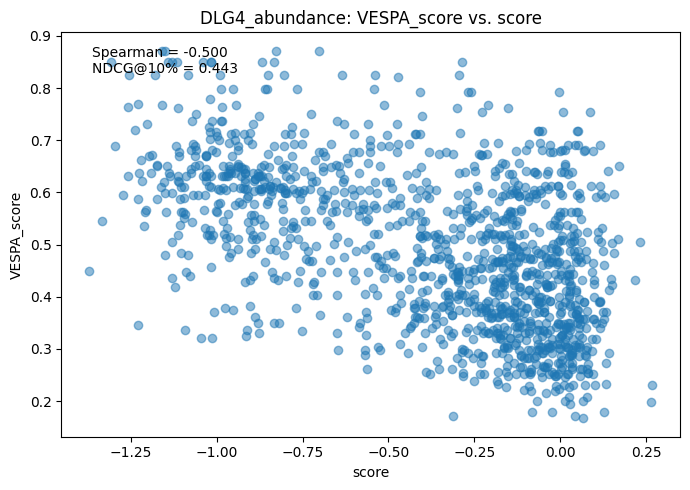


DLG4_binding / score: {'n': 1441, 'pearson': -0.6295064236380439, 'spearman': -0.632072697363574, 'ndcg@10%': 0.42724979849717587}


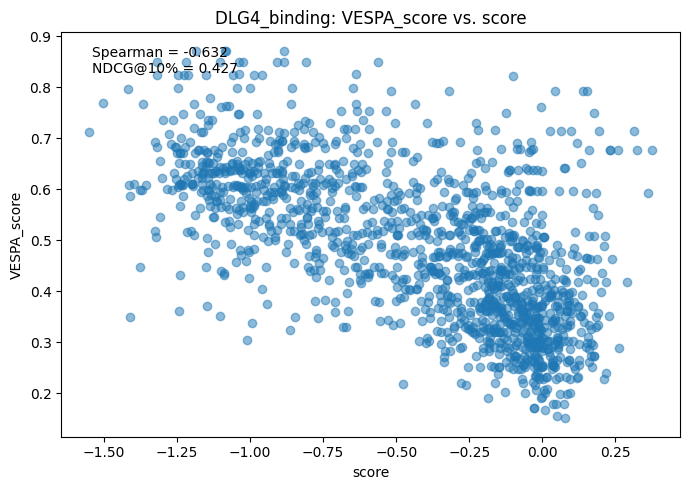

,dataset,target,n,pearson,spearman,ndcg@10%
0,DLG4_abundance,score,1280,-0.525,-0.500,0.443
1,DLG4_binding,score,1441,-0.630,-0.632,0.427


In [10]:
# Evaluate benchmark datasets
benchmark_metrics = []

for dataset_name, df in benchmark_results.items():
    target_cols = datasets[dataset_name]["config"]["target_cols"]

    for target_col in target_cols:
        metrics = evaluate_scores(df, target_col=target_col, score_col=SCORE_COL)
        benchmark_metrics.append({"dataset": dataset_name, "target": target_col, **metrics})
        print(f"\n{dataset_name} / {target_col}: {metrics}")
        plot_scores(df, dataset_name=dataset_name, target_col=target_col, score_col=SCORE_COL)

benchmark_metrics_df = pd.DataFrame(benchmark_metrics)
display(benchmark_metrics_df.round(3))

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np

PETASE_FULL_RANK_PATH = Path(
    "/Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/Ensemble/petase_full_rank.csv"
)

UPDATED_FULL_RANK_PATH = PETASE_FULL_RANK_PATH.with_name(
    "petase_full_rank_vespa_updated.csv"
)

VESPA_WORK_DIR = Path(
    "/Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/VESPA/petase"
)

FASTA_DIR = VESPA_WORK_DIR / "fasta"
RUN_ROOT = VESPA_WORK_DIR / "runs"
CACHE_DIR = VESPA_WORK_DIR / "cache"
PETASE_OUTPUT_DIR = VESPA_WORK_DIR / "outputs"

for d in [FASTA_DIR, RUN_ROOT, CACHE_DIR, PETASE_OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

petase_full = pd.read_csv(PETASE_FULL_RANK_PATH)

print("Loaded:", PETASE_FULL_RANK_PATH)
print("Shape:", petase_full.shape)
print("Columns:")
print(petase_full.columns.tolist())

display(petase_full.head())

Loaded: /Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/Ensemble/petase_full_rank.csv
Shape: (4678, 15)
Columns:
['sequence', 'variant', 'eve_index', 'esm3_index', 'esmIF_index', 'vespa_score', 'prosst', 'esm_index', 'eve_index_rank', 'esm_index_rank', 'esm3_index_rank', 'esmIF_index_rank', 'vespa_score_rank', 'prosst_rank', 'full_rank']


,sequence,variant,eve_index,esm3_index,esmIF_index,vespa_score,prosst,esm_index,eve_index_rank,esm_index_rank,esm3_index_rank,esmIF_index_rank,vespa_score_rank,prosst_rank,full_rank
0,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127I,-8.537994,-20.598639,-28.530201,-0.902211,-19.999733,-16.725388,196,5,45,2,1,2,1
1,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133I,-8.342529,-23.177387,-27.325787,-0.837786,-13.836625,-14.752697,407,42,7,7,129,147,2
2,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G132I,-8.715027,-22.345913,-26.289278,-0.808987,-13.928497,-14.132256,48,83,11,10,199,144,3
3,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133L,-8.801453,-21.698158,-23.767323,-0.837786,-12.557037,-14.790074,17,41,24,52,130,212,4
4,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,W225P,-8.530151,-19.336689,-24.000996,-0.836038,-14.262654,-15.462068,202,20,81,48,133,120,5


In [28]:
cols_to_drop = [
    c for c in petase_full.columns
    if c.lower().startswith("vespa") or c == "full_rank"
]

petase_base = petase_full.drop(columns=cols_to_drop, errors="ignore").copy()

print("Dropped columns:")
print(cols_to_drop)

print("\nRemaining columns:")
print(petase_base.columns.tolist())

display(petase_base.head())

Dropped columns:
['vespa_score', 'vespa_score_rank', 'full_rank']

Remaining columns:
['sequence', 'variant', 'eve_index', 'esm3_index', 'esmIF_index', 'prosst', 'esm_index', 'eve_index_rank', 'esm_index_rank', 'esm3_index_rank', 'esmIF_index_rank', 'prosst_rank']


,sequence,variant,eve_index,esm3_index,esmIF_index,prosst,esm_index,eve_index_rank,esm_index_rank,esm3_index_rank,esmIF_index_rank,prosst_rank
0,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127I,-8.537994,-20.598639,-28.530201,-19.999733,-16.725388,196,5,45,2,2
1,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133I,-8.342529,-23.177387,-27.325787,-13.836625,-14.752697,407,42,7,7,147
2,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G132I,-8.715027,-22.345913,-26.289278,-13.928497,-14.132256,48,83,11,10,144
3,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133L,-8.801453,-21.698158,-23.767323,-12.557037,-14.790074,17,41,24,52,212
4,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,W225P,-8.530151,-19.336689,-24.000996,-14.262654,-15.462068,202,20,81,48,120


In [29]:
# PETase-Varianten sind 0-basiert
POSITION_BASE = 0

def reconstruct_wt_sequence_safe(row, position_base=0):
    variant = str(row["variant"])
    sequence = row["sequence"]

    # WT-Zeilen sind schon WT-Sequenzen
    if variant.upper() == "WT":
        return sequence

    return reconstruct_wild_type_sequence(
        mutated_sequence=sequence,
        variant=variant,
        position_base=position_base,
    )

petase_base["reconstructed_wt_sequence"] = petase_base.apply(
    lambda row: reconstruct_wt_sequence_safe(row, position_base=POSITION_BASE),
    axis=1,
)

print("Number of reconstructed WT sequences:")
print(petase_base["reconstructed_wt_sequence"].nunique())

print("\nCounts per WT sequence:")
print(petase_base["reconstructed_wt_sequence"].value_counts())

Number of reconstructed WT sequences:
3

Counts per WT sequence:
reconstructed_wt_sequence
AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPTDTSQTYGAVVIVPGFISVWAQLNWLGPRLASQGFVVIGIETSVITDLPDPRGDQALAALDWATTRSPVASRIDRTRLAAAGWSMGGGGLRRAALQRPSLKAIVGMAPWNGERNWSAVTVPTLFFGGSSDAVASPNDHAKPFYNSITRAEKDYIELRNADHFFPTSANTTMAKYFISWLKRWVDNDTRYTQFLCPGPSTGLFAPVSASMNTCPF    1560
ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTDTSQGTFGAVAIVPGYTATWAAEGAWMGHWLASFGFVVIGIDTINRNDWDTARGTQLLAALDYLTQRSTVRDRVDASRLAVMGHSMGGGGAMYAALQRPSLKAAVGLAPFSPSQNLNGMRVPTMLLAGQHDTTTTPASITSLYNGIPAATEKAYLELSGAGHGFPTSNNSVMMRKVIPWLKIFVDSDVRYTQFLCPLMDNTGIRSYQSTCPL      1559
AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYPTSTADGRFGVVAISPGYTASESTIAWLGPRLASFGFVVVTINTDSRYDQPRQRATQLHAALDHAIGDSVVGPRIDTSRQAVMGHSMGGGGALQAAEERDEIRAAVPLTPWNLKKGWSGVDAATLVIGAENDAIAPVRSHSIPFYESLTNAERRAYLELRREGHFAPNSSNTLIAKYSVSWLKRYVDNDLRYDQFIDPGPRTGITTGVSDYRLG    1559
Name: count, dtype: int64


In [30]:
wt_sequences = (
    petase_base["reconstructed_wt_sequence"]
    .drop_duplicates()
    .reset_index(drop=True)
)

wt_sequence_to_name = {
    wt_seq: f"WT_{i+1}"
    for i, wt_seq in enumerate(wt_sequences)
}

petase_base["petase_wt"] = petase_base["reconstructed_wt_sequence"].map(wt_sequence_to_name)

print("WT groups:")
print(petase_base["petase_wt"].value_counts())

WT groups:
petase_wt
WT_3    1560
WT_1    1559
WT_2    1559
Name: count, dtype: int64


In [31]:
petase_base = petase_base.copy()

# Falls row_id schon existiert, sauber neu setzen
petase_base = petase_base.drop(columns=["row_id"], errors="ignore")
petase_base["row_id"] = np.arange(len(petase_base))

print(petase_base[["row_id", "sequence", "variant", "petase_wt"]].head())

   row_id                                           sequence variant petase_wt
0       0  ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...   G127I      WT_1
1       1  AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...   G133I      WT_2
2       2  ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...   G132I      WT_1
3       3  AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...   G133L      WT_2
4       4  AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...   W225P      WT_2


In [32]:
PETASE_CONFIG = {}

for wt_name in sorted(petase_base["petase_wt"].unique()):
    PETASE_CONFIG[wt_name] = {
        "protein_id": f"PETASE_{wt_name}",
        "fasta_header": f"PETASE_{wt_name}",
        "position_base": POSITION_BASE,
        "score_higher_is_better": True,
    }

PETASE_CONFIG

{'WT_1': {'protein_id': 'PETASE_WT_1',
  'fasta_header': 'PETASE_WT_1',
  'position_base': 0,
  'score_higher_is_better': True},
 'WT_2': {'protein_id': 'PETASE_WT_2',
  'fasta_header': 'PETASE_WT_2',
  'position_base': 0,
  'score_higher_is_better': True},
 'WT_3': {'protein_id': 'PETASE_WT_3',
  'fasta_header': 'PETASE_WT_3',
  'position_base': 0,
  'score_higher_is_better': True}}

In [33]:
petase_datasets = {}

for wt_name, config in PETASE_CONFIG.items():
    df = petase_base.loc[petase_base["petase_wt"] == wt_name].copy()
    df = df.reset_index(drop=True)

    wt_sequence = df.loc[0, "reconstructed_wt_sequence"]

    # Für VESPA nur echte Mutationen verwenden.
    # WT-Zeilen bekommen später vespa_score = 0.
    df_mut = df.loc[df["variant"].astype(str).str.upper() != "WT"].copy()
    df_mut = df_mut.reset_index(drop=True)

    fasta_path = FASTA_DIR / f"{config['protein_id']}.fasta"

    write_fasta(
        sequence=wt_sequence,
        fasta_path=fasta_path,
        header=config["fasta_header"],
    )

    petase_datasets[wt_name] = {
        "df": df_mut,
        "config": config,
        "fasta_path": fasta_path,
        "wt_sequence": wt_sequence,
    }

    print(f"{wt_name}")
    print(f"  total rows:     {len(df)}")
    print(f"  mutant rows:    {len(df_mut)}")
    print(f"  row_id in data: {'row_id' in df_mut.columns}")
    print(f"  WT length:      {len(wt_sequence)}")
    print(f"  FASTA:          {fasta_path}")

WT_1
  total rows:     1559
  mutant rows:    1558
  row_id in data: True
  WT length:      257
  FASTA:          /Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/VESPA/petase/fasta/PETASE_WT_1.fasta
WT_2
  total rows:     1559
  mutant rows:    1558
  row_id in data: True
  WT length:      259
  FASTA:          /Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/VESPA/petase/fasta/PETASE_WT_2.fasta
WT_3
  total rows:     1560
  mutant rows:    1558
  row_id in data: True
  WT length:      259
  FASTA:          /Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/VESPA/petase/fasta/PETASE_WT_3.fasta


In [34]:
for wt_name, item in petase_datasets.items():
    df = item["df"]
    wt_sequence = item["wt_sequence"]

    n_checked = 0
    n_ok_mutated = 0
    n_ok_wt = 0

    for _, row in df.head(200).iterrows():
        parsed = parse_variant(row["variant"])
        if parsed is None:
            continue

        wt_aa, pos, mut_aa = parsed
        idx = pos  # PETase ist 0-basiert

        if 0 <= idx < len(row["sequence"]):
            n_checked += 1

            if row["sequence"][idx] == mut_aa:
                n_ok_mutated += 1

            if wt_sequence[idx] == wt_aa:
                n_ok_wt += 1

    print(f"{wt_name}:")
    print(f"  mutated sequence check: {n_ok_mutated}/{n_checked}")
    print(f"  WT sequence check:      {n_ok_wt}/{n_checked}")

WT_1:
  mutated sequence check: 200/200
  WT sequence check:      200/200
WT_2:
  mutated sequence check: 200/200
  WT sequence check:      200/200
WT_3:
  mutated sequence check: 200/200
  WT sequence check:      200/200


In [35]:
petase_vespa_results = {}
petase_vespa_meta = {}

for wt_name, item in petase_datasets.items():
    config = item["config"]

    print(f"\n===== Running VESPA for {wt_name} =====")

    merged, meta = run_vespa_for_dataset(
        item["df"],
        fasta_path=item["fasta_path"],
        protein_id=config["protein_id"],
        variant_col="variant",
        position_base=config["position_base"],
        score_higher_is_better=config.get("score_higher_is_better", True),
        cache_dir=CACHE_DIR,
        run_root=RUN_ROOT,
        threads=1,
    )

    print("Returned columns:")
    print(merged.columns.tolist())

    # VESPA-Score-Spalte robust erkennen
    vespa_score_candidates = [
        c for c in merged.columns
        if c.lower() in ["vespa_score", "vespa score"]
    ]

    if len(vespa_score_candidates) == 0:
        raise ValueError(
            "Keine VESPA-Score-Spalte gefunden. "
            f"Vorhandene Spalten: {merged.columns.tolist()}"
        )

    vespa_score_col = vespa_score_candidates[0]
    merged = merged.rename(columns={vespa_score_col: "vespa_score"})

    if "petase_wt" not in merged.columns:
        merged["petase_wt"] = wt_name

    if "row_id" not in merged.columns:
        raise ValueError(
            "row_id fehlt nach run_vespa_for_dataset. "
            f"Vorhandene Spalten: {merged.columns.tolist()}"
        )

    cleaned = merged[["row_id", "petase_wt", "sequence", "variant", "vespa_score"]].copy()

    out_path = PETASE_OUTPUT_DIR / f"{wt_name}_vespa_predictions.csv"
    cleaned.to_csv(out_path, index=False)

    print(f"Saved: {out_path}")
    display(cleaned.head())

    petase_vespa_results[wt_name] = cleaned
    petase_vespa_meta[wt_name] = meta


===== Running VESPA for WT_1 =====
[PETASE_WT_1] FASTA ID: PETASE_WT_1
[PETASE_WT_1] Valid mutations: 1558 unique / 1558 rows
[PETASE_WT_1] Running VESPA
[PETASE_WT_1] Saved scores: 1558 / 1558
[PETASE_WT_1] NaNs in VESPA_score: 0
Returned columns:
['sequence', 'variant', 'eve_index', 'esm3_index', 'esmIF_index', 'prosst', 'esm_index', 'eve_index_rank', 'esm_index_rank', 'esm3_index_rank', 'esmIF_index_rank', 'prosst_rank', 'reconstructed_wt_sequence', 'petase_wt', 'row_id', 'vespa_key', 'Mutant', 'VESPAl', 'VESPA_score']
Saved: /Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/VESPA/petase/outputs/WT_1_vespa_predictions.csv


,row_id,petase_wt,sequence,variant,vespa_score
0,0,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127I,0.902211
1,2,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G132I,0.808987
2,5,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127P,0.865528
3,11,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127K,0.865528
4,13,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127V,0.885140



===== Running VESPA for WT_2 =====
[PETASE_WT_2] FASTA ID: PETASE_WT_2
[PETASE_WT_2] Valid mutations: 1558 unique / 1558 rows
[PETASE_WT_2] Running VESPA
[PETASE_WT_2] Saved scores: 1558 / 1558
[PETASE_WT_2] NaNs in VESPA_score: 0
Returned columns:
['sequence', 'variant', 'eve_index', 'esm3_index', 'esmIF_index', 'prosst', 'esm_index', 'eve_index_rank', 'esm_index_rank', 'esm3_index_rank', 'esmIF_index_rank', 'prosst_rank', 'reconstructed_wt_sequence', 'petase_wt', 'row_id', 'vespa_key', 'Mutant', 'VESPAl', 'VESPA_score']
Saved: /Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/VESPA/petase/outputs/WT_2_vespa_predictions.csv


,row_id,petase_wt,sequence,variant,vespa_score
0,1,WT_2,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133I,0.837786
1,3,WT_2,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133L,0.837786
2,4,WT_2,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,W225P,0.836038
3,8,WT_2,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133Y,0.811833
4,9,WT_2,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133F,0.811833



===== Running VESPA for WT_3 =====
[PETASE_WT_3] FASTA ID: PETASE_WT_3
[PETASE_WT_3] Valid mutations: 1558 unique / 1558 rows
[PETASE_WT_3] Running VESPA
[PETASE_WT_3] Saved scores: 1558 / 1558
[PETASE_WT_3] NaNs in VESPA_score: 0
Returned columns:
['sequence', 'variant', 'eve_index', 'esm3_index', 'esmIF_index', 'prosst', 'esm_index', 'eve_index_rank', 'esm_index_rank', 'esm3_index_rank', 'esmIF_index_rank', 'prosst_rank', 'reconstructed_wt_sequence', 'petase_wt', 'row_id', 'vespa_key', 'Mutant', 'VESPAl', 'VESPA_score']
Saved: /Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/VESPA/petase/outputs/WT_3_vespa_predictions.csv


,row_id,petase_wt,sequence,variant,vespa_score
0,6,WT_3,AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPT...,G126I,0.899099
1,7,WT_3,AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPT...,G126K,0.861430
2,15,WT_3,AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPT...,G78I,0.875128
3,20,WT_3,AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPT...,G126L,0.899099
4,21,WT_3,AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPT...,G126M,0.881556


In [36]:
vespa_all = pd.concat(
    petase_vespa_results.values(),
    axis=0,
    ignore_index=True,
)

dup_mask = vespa_all.duplicated(subset=["row_id"], keep=False)

if dup_mask.any():
    print("Warnung: doppelte row_id in VESPA-Ergebnissen gefunden.")
    display(vespa_all.loc[dup_mask].sort_values("row_id").head(20))

    # Falls doppelte row_ids auftauchen, ersten Eintrag behalten
    vespa_all = vespa_all.drop_duplicates(subset=["row_id"], keep="first")

print("VESPA total rows:", len(vespa_all))
display(vespa_all.head())

VESPA total rows: 4674


,row_id,petase_wt,sequence,variant,vespa_score
0,0,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127I,0.902211
1,2,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G132I,0.808987
2,5,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127P,0.865528
3,11,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127K,0.865528
4,13,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127V,0.885140


In [37]:
updated = petase_base.merge(
    vespa_all[["row_id", "vespa_score"]],
    on="row_id",
    how="left",
    validate="one_to_one",
)

print("Updated shape:", updated.shape)
print("Missing VESPA predictions before WT fill:", updated["vespa_score"].isna().sum())

display(
    updated.loc[
        updated["vespa_score"].isna(),
        ["row_id", "petase_wt", "sequence", "variant"]
    ].head(30)
)

Updated shape: (4678, 16)
Missing VESPA predictions before WT fill: 4


,row_id,petase_wt,sequence,variant
4633,4633,WT_3,AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPT...,WT
4634,4634,WT_3,AADNPYQRGPDPTNASIEAATGPFAVGTQPIVGASGFGGGQIYYPT...,WT
4635,4635,WT_1,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,WT
4636,4636,WT_2,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,WT


In [39]:
updated.loc[
    updated["variant"].astype(str).str.upper() == "WT",
    "vespa_score"
] = 0.0

print("Missing VESPA predictions after WT fill:", updated["vespa_score"].isna().sum())

Missing VESPA predictions after WT fill: 0


In [41]:
updated_final = updated.drop(
    columns=["reconstructed_wt_sequence", "petase_wt", "row_id"],
    errors="ignore",
)

display(updated_final.head())
print(updated_final.columns.tolist())
print(updated_final.shape)

,sequence,variant,eve_index,esm3_index,esmIF_index,prosst,esm_index,eve_index_rank,esm_index_rank,esm3_index_rank,esmIF_index_rank,prosst_rank,vespa_score
0,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G127I,-8.537994,-20.598639,-28.530201,-19.999733,-16.725388,196,5,45,2,2,0.902211
1,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133I,-8.342529,-23.177387,-27.325787,-13.836625,-14.752697,407,42,7,7,147,0.837786
2,ADNPYQRGPDPTRDSVAASRGTFATASTTVGSGNGFGAGFIYYPTD...,G132I,-8.715027,-22.345913,-26.289278,-13.928497,-14.132256,48,83,11,10,144,0.808987
3,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,G133L,-8.801453,-21.698158,-23.767323,-12.557037,-14.790074,17,41,24,52,212,0.837786
4,AQNPHERGPDPSNSYIEQARGSYSVSQRSISRLGSDGFRDGTMYYP...,W225P,-8.530151,-19.336689,-24.000996,-14.262654,-15.462068,202,20,81,48,120,0.836038


['sequence', 'variant', 'eve_index', 'esm3_index', 'esmIF_index', 'prosst', 'esm_index', 'eve_index_rank', 'esm_index_rank', 'esm3_index_rank', 'esmIF_index_rank', 'prosst_rank', 'vespa_score']
(4678, 13)


In [42]:
updated_final.to_csv(UPDATED_FULL_RANK_PATH, index=False)

print("Saved updated PETase full-rank file to:")
print(UPDATED_FULL_RANK_PATH)

Saved updated PETase full-rank file to:
/Users/kevinbauer/Desktop/Masterarbeit/Zero-Shot_Phase/BetaTest/Ensemble/petase_full_rank_vespa_updated.csv
